# Stress Test Exploratory Data Analysis (EDA)

This notebook performs EDA on the `stress_test_log.csv` file generated during the model stress tests.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [3]:
# Load the data
LOG_FILE = "stress_test_log.csv"

if os.path.exists(LOG_FILE):
    df = pd.read_csv(LOG_FILE)
    # Convert time columns to datetime
    df['start_time'] = pd.to_datetime(df['start_time'])
    df['end_time'] = pd.to_datetime(df['end_time'])
    print("Data loaded successfully.")
    display(df.head())
else:
    print(f"Error: {LOG_FILE} not found. Please ensure it is in the same directory or adjust the path.")

Data loaded successfully.


,test_scenario,model_name,file_name,start_time,end_time,time_taken_sec,vram_used_mb,status,error,output_file
0,VLM_Inference_Loop,PaddleOCR-VL,invoice001.jpg,2026-04-14 07:09:44,2026-04-14 07:09:48,3.684,12893,success,NaN,../stress_results_vlm/vlm_out_000_invoice001.j...
1,VLM_Inference_Loop,PaddleOCR-VL,invoice002.jpg,2026-04-14 07:09:48,2026-04-14 07:09:50,2.254,12941,success,NaN,../stress_results_vlm/vlm_out_001_invoice002.j...
2,VLM_Inference_Loop,PaddleOCR-VL,invoice003.jpg,2026-04-14 07:09:50,2026-04-14 07:09:54,3.392,12941,success,NaN,../stress_results_vlm/vlm_out_002_invoice003.j...
3,VLM_Inference_Loop,PaddleOCR-VL,invoice004.jpg,2026-04-14 07:09:54,2026-04-14 07:09:56,2.232,12941,success,NaN,../stress_results_vlm/vlm_out_003_invoice004.j...
4,VLM_Inference_Loop,PaddleOCR-VL,invoice005.jpg,2026-04-14 07:09:56,2026-04-14 07:09:58,1.813,12941,success,NaN,../stress_results_vlm/vlm_out_004_invoice005.j...


## 1. Performance & Latency Analysis

/tmp/ipykernel_533145/4262413175.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_latency.index, y=avg_latency.values, palette="viridis")


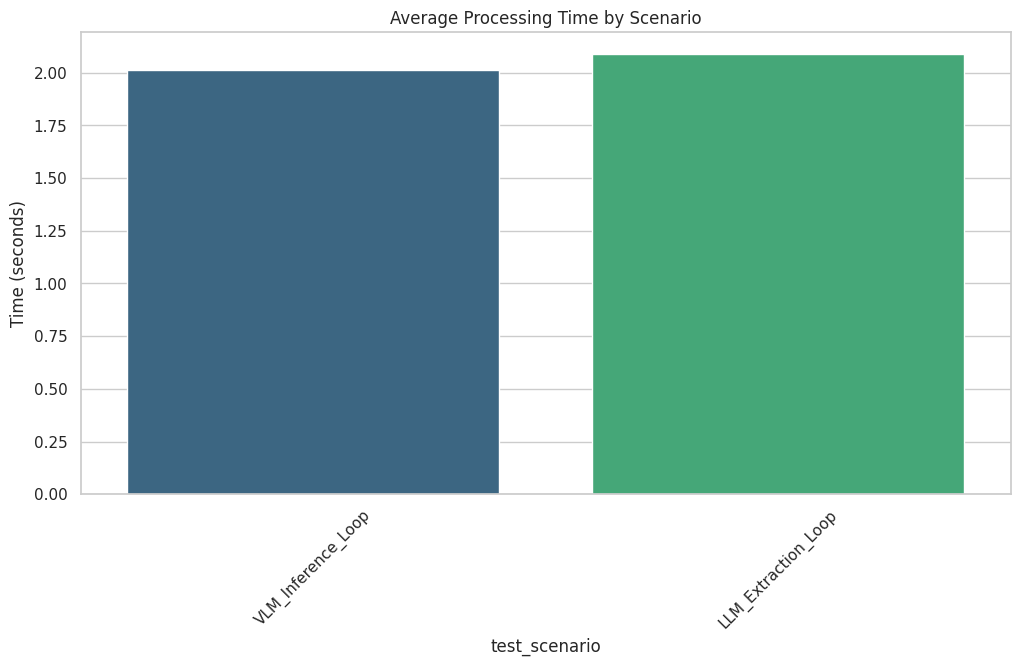

In [4]:
# 1a. Average Processing Time per Scenario
avg_latency = df.groupby('test_scenario')['time_taken_sec'].mean().sort_values()
sns.barplot(x=avg_latency.index, y=avg_latency.values, palette="viridis")
plt.title("Average Processing Time by Scenario")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_533145/9065708.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='test_scenario', y='time_taken_sec', palette="Set2")


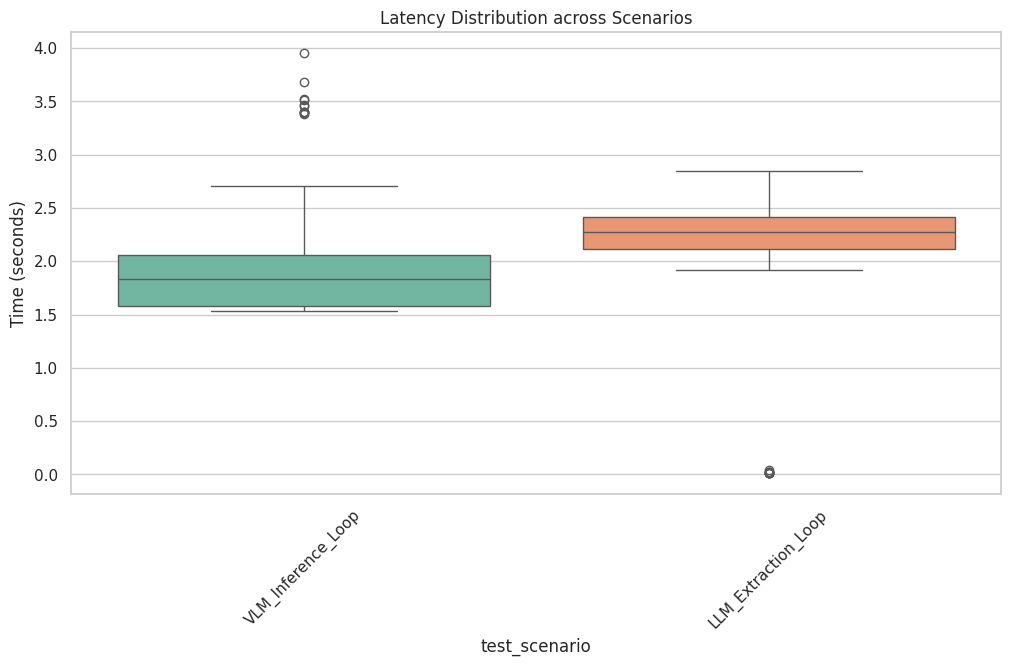

In [5]:
# 1b. Latency Distribution (Spread)
sns.boxplot(data=df, x='test_scenario', y='time_taken_sec', palette="Set2")
plt.title("Latency Distribution across Scenarios")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=45)
plt.show()

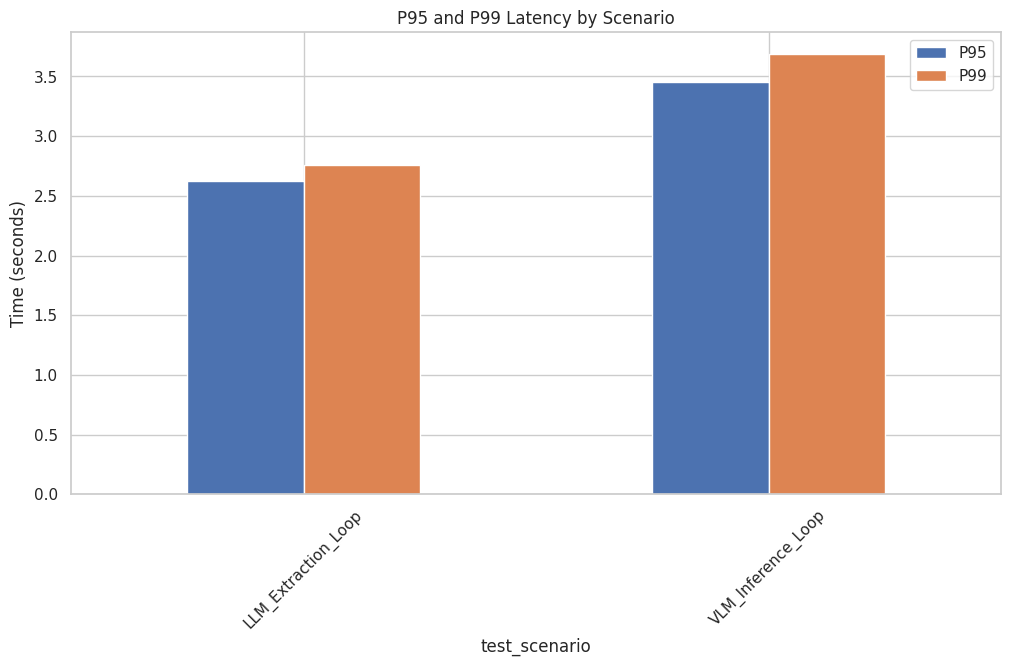

In [6]:
# 1c. P95 and P99 Latency (Worst-case performance)
percentiles = df.groupby('test_scenario')['time_taken_sec'].quantile([0.95, 0.99]).unstack()
percentiles.plot(kind='bar')
plt.title("P95 and P99 Latency by Scenario")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=45)
plt.legend(["P95", "P99"])
plt.show()

## 2. Reliability & Error Profiling

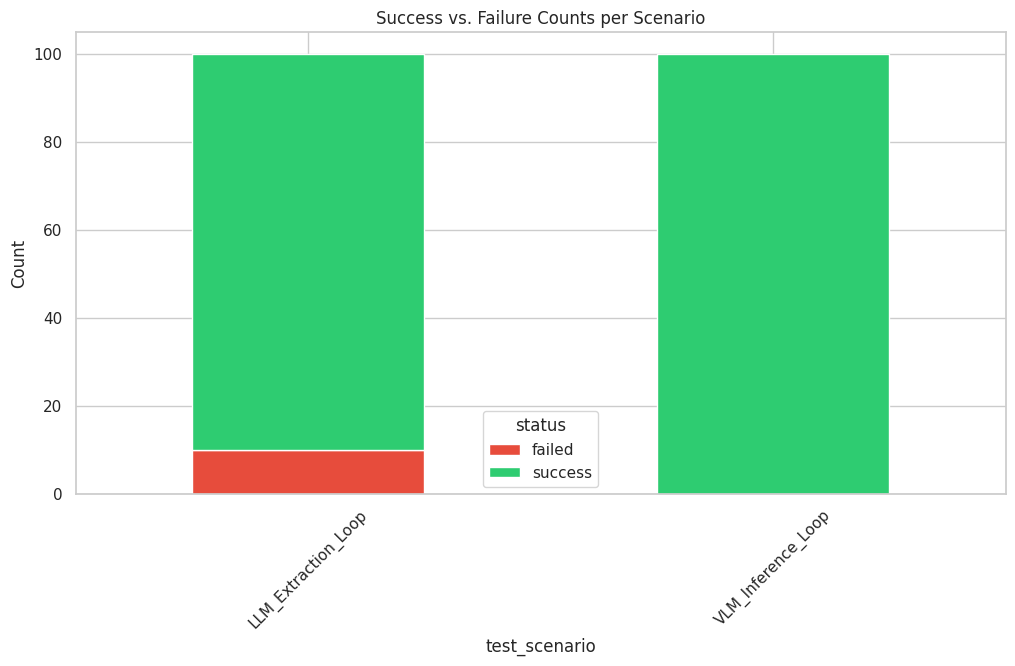

In [7]:
# 2a. Success vs. Failure Rate
status_counts = df.groupby(['test_scenario', 'status']).size().unstack(fill_value=0)
status_counts.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71'])
plt.title("Success vs. Failure Counts per Scenario")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_533145/1955561970.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=error_counts.index, x=error_counts.values, palette="Reds_r")


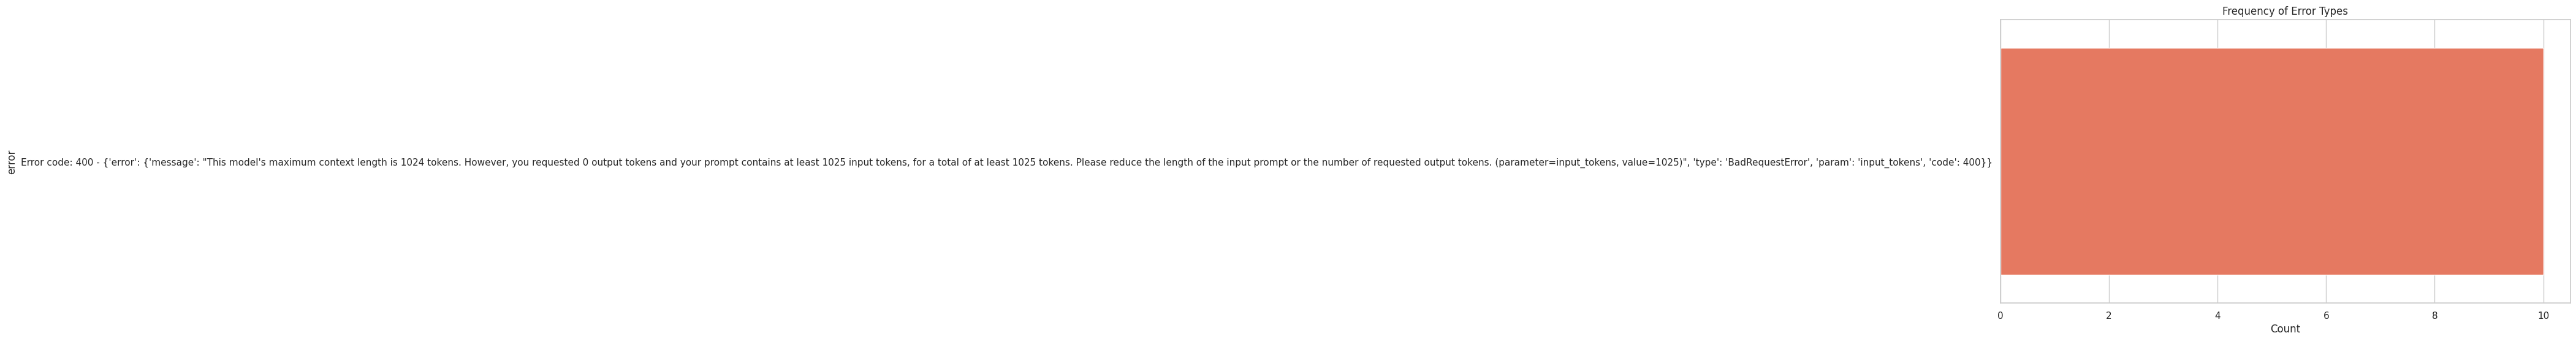

In [8]:
# 2b. Error Categorization
errors_df = df[df['status'] == 'failed']
if not errors_df.empty:
    error_counts = errors_df['error'].value_counts()
    sns.barplot(y=error_counts.index, x=error_counts.values, palette="Reds_r")
    plt.title("Frequency of Error Types")
    plt.xlabel("Count")
    plt.show()
else:
    print("No errors found in the log.")

## 3. Resource Stability (VRAM Analysis)

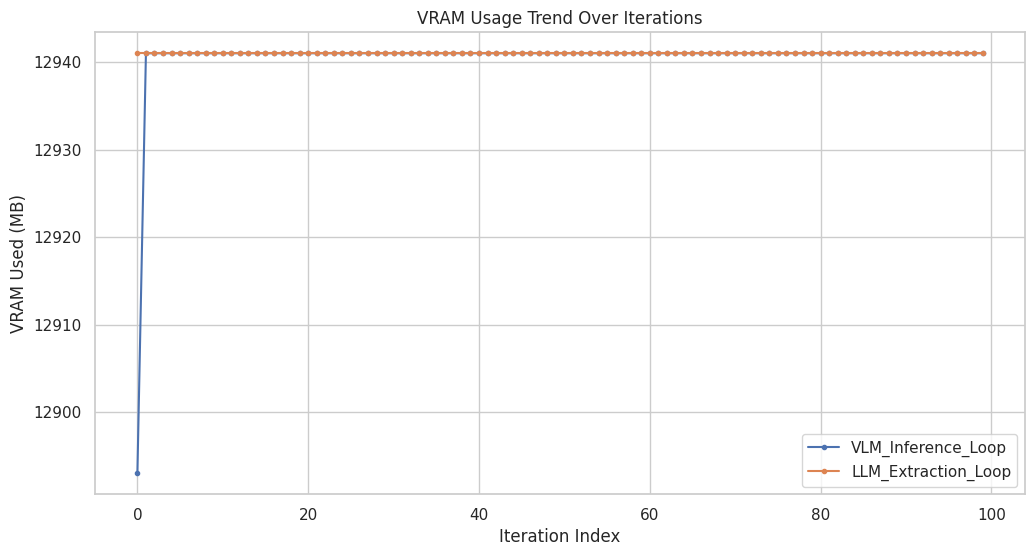

In [9]:
# 3a. VRAM Consumption Trend Over Time
for scenario in df['test_scenario'].unique():
    subset = df[df['test_scenario'] == scenario].reset_index()
    plt.plot(subset.index, subset['vram_used_mb'], label=scenario, marker='o', markersize=3)

plt.title("VRAM Usage Trend Over Iterations")
plt.xlabel("Iteration Index")
plt.ylabel("VRAM Used (MB)")
plt.legend()
plt.show()

/tmp/ipykernel_533145/1154554995.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='test_scenario', y='vram_used_mb', palette="coolwarm")


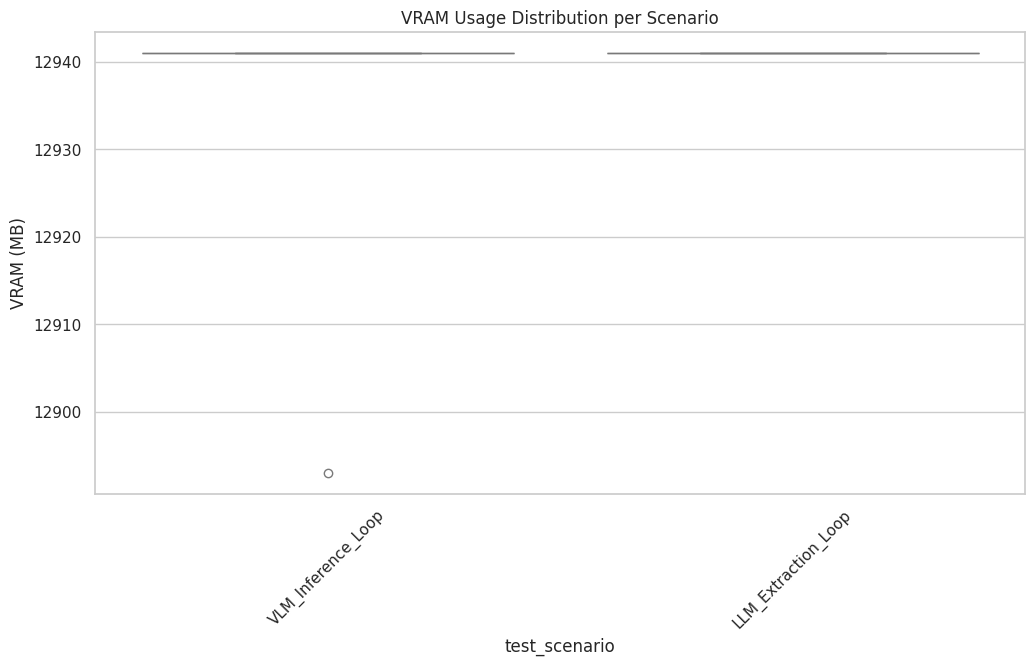

In [10]:
# 3b. VRAM Stability: Boxplot per Scenario
sns.boxplot(data=df, x='test_scenario', y='vram_used_mb', palette="coolwarm")
plt.title("VRAM Usage Distribution per Scenario")
plt.ylabel("VRAM (MB)")
plt.xticks(rotation=45)
plt.show()

## 4. Temporal Trends (Aging Analysis)

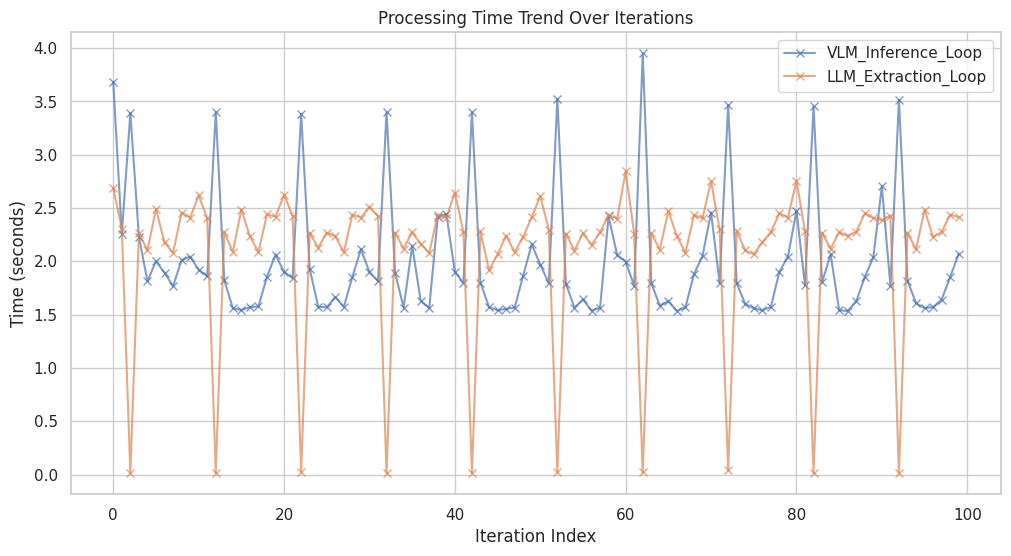

In [11]:
# 4a. Time Taken to Process File Over Time
for scenario in df['test_scenario'].unique():
    subset = df[df['test_scenario'] == scenario].reset_index()
    plt.plot(subset.index, subset['time_taken_sec'], label=scenario, marker='x', alpha=0.7)

plt.title("Processing Time Trend Over Iterations")
plt.xlabel("Iteration Index")
plt.ylabel("Time (seconds)")
plt.legend()
plt.show()

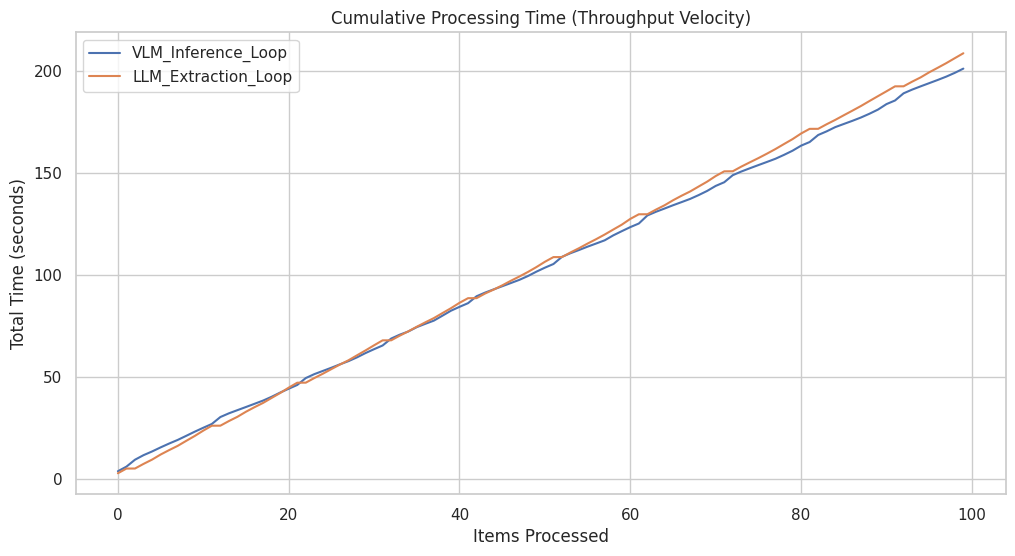

In [12]:
# 4b. Cumulative Time Taken (Processing Velocity)
for scenario in df['test_scenario'].unique():
    subset = df[df['test_scenario'] == scenario].copy().reset_index()
    subset['cumulative_time'] = subset['time_taken_sec'].cumsum()
    plt.plot(subset.index, subset['cumulative_time'], label=scenario)

plt.title("Cumulative Processing Time (Throughput Velocity)")
plt.xlabel("Items Processed")
plt.ylabel("Total Time (seconds)")
plt.legend()
plt.show()

## 5. Cross-Scenario Insights

In [13]:
# 5a. Bottleneck Identification
# Compare VLM (Scenario 1) and LLM (Scenario 2) means
vlm_mean = df[df['test_scenario'] == 'VLM_Inference_Loop']['time_taken_sec'].mean()
llm_mean = df[df['test_scenario'] == 'LLM_Extraction_Loop']['time_taken_sec'].mean()

if not np.isnan(vlm_mean) and not np.isnan(llm_mean):
    ratio = llm_mean / vlm_mean
    print(f"VLM Mean Latency: {vlm_mean:.3f}s")
    print(f"LLM Mean Latency: {llm_mean:.3f}s")
    print(f"Ratio (LLM/VLM): {ratio:.2f}x")
    
    if ratio > 1:
        print("Insight: The LLM extraction is currently the bottleneck.")
    else:
        print("Insight: The VLM OCR is currently the bottleneck.")

VLM Mean Latency: 2.012s
LLM Mean Latency: 2.088s
Ratio (LLM/VLM): 1.04x
Insight: The LLM extraction is currently the bottleneck.


/tmp/ipykernel_533145/179969295.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_slow_files.values, y=top_slow_files.index, palette="magma")


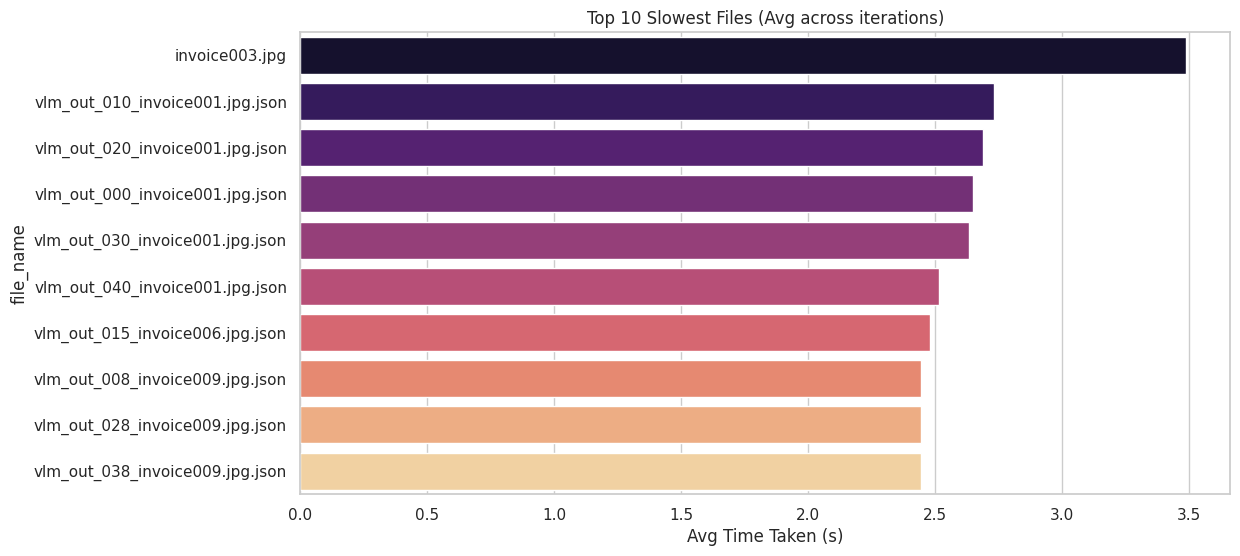

In [14]:
# 5b. Repeatability (Impact of File Content)
# Check if specific files always take longer across all iterations
top_slow_files = df.groupby('file_name')['time_taken_sec'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_slow_files.values, y=top_slow_files.index, palette="magma")
plt.title("Top 10 Slowest Files (Avg across iterations)")
plt.xlabel("Avg Time Taken (s)")
plt.show()